# Nacimientos en Chile entre 2020 y 2023
## Fase 2 — Preparación y análisis preliminar de calidad

**Grupo 2:** Cristian Hurtado, Jorge Altamirano y Renzo Vilchez.  
**Repositorio:** https://github.com/jorgealtamiranonavarrete-art/proyecto-grupo2

Este notebook adapta el ejemplo docente `S1_F2_Preprocesamiento.ipynb` de MCDI500, Universidad Andrés Bello.
Construye un flujo de carga, diagnóstico, preparación, comparación de imputaciones y validación para
un análisis descriptivo. Incorpora mapas de calor de nulos y faltantes por región de residencia materna.

Las preguntas son: porcentaje regional de nacimientos de madres menores de 20 años, promedio diario
por mes y talla promedio regional. Se considera **2020–2023 acumulado**, con todas las edades maternas
en las preguntas mensual y de talla. El notebook estudia calidad y sensibilidad de los datos;
los rankings definitivos de los tres indicadores se elaborarán después de aprobar las decisiones.

Las salidas incluidas se generaron con el CSV proporcionado en un entorno de apoyo. El equipo debe
volver a ejecutar el notebook en su entorno y guardar esa evidencia antes de entregar.

### Objetivos y ejecución
- Diagnosticar nulos, dominios, valores extremos y filas iguales antes de transformar.
- Comparar cantidades y porcentajes de faltantes por región, con denominadores explícitos.
- Evaluar casos observados, media general, mediana general y mediana regional para talla.
- Preparar variables con funciones reutilizables y verificar que los nacimientos se conservan.
- Exportar una propuesta trazable para revisión del grupo.

Guardar como `F2/F2_Preparacion.ipynb`. Requiere pandas, NumPy, Matplotlib e ipykernel en el entorno
seleccionado en VS Code. Ejecutar desde un kernel reiniciado. El CSV debe existir en
`data/raw/Serie_Nacimientos_2020_2023.csv`. No se modifica el original ni se ejecutan commits.
No se utiliza muestreo ni aleatoriedad; los mapas resumen la totalidad de los registros.

In [1]:
from pathlib import Path
from datetime import date
from importlib import metadata
import importlib.util
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")

def encontrar_raiz(inicio):
    for ruta in (Path(inicio).resolve(), *Path(inicio).resolve().parents):
        if all((ruta / c).is_dir() for c in ('F1','F2','data')):
            return ruta
    raise FileNotFoundError('Ejecute dentro del repositorio con F1/, F2/ y data/.')

RAIZ = encontrar_raiz(Path.cwd())
ARCHIVO = RAIZ / 'data/raw/Serie_Nacimientos_2020_2023.csv'
DOCS = RAIZ / 'docs/f2'
FIGURAS = RAIZ / 'outputs/f2'
PROCESADOS = RAIZ / 'data/processed'
for carpeta in (DOCS, FIGURAS, PROCESADOS, RAIZ / 'src'):
    carpeta.mkdir(parents=True, exist_ok=True)
VERSIONES = {p: metadata.version(p) for p in ('pandas','numpy','matplotlib')}
print('Python:', platform.python_version(), '| Fecha:', date.today().isoformat())
print('Versiones:', VERSIONES)
print('Fuente relativa:', ARCHIVO.relative_to(RAIZ))

Python: 3.13.5 | Fecha: 2026-09-18
Versiones: {'pandas': '3.0.5', 'numpy': '2.5.3', 'matplotlib': '3.11.2'}
Fuente relativa: data\raw\Serie_Nacimientos_2020_2023.csv


## 1. Fuente y funciones del procesamiento
**Fuente:** DEIS/MINSAL, *Serie de nacimientos 2020–2023*, https://deis.minsal.cl/#datosabiertos.
La ficha `Fichas DA Nacimientos.xlsx` documenta los campos. Una fila es un nacido vivo inscrito;
la región corresponde a la residencia de la madre. Se esperan 735.611 filas y 25 columnas.

**Fecha original de descarga:** 15 de septiembre de 2026.

**Versión publicada o url directa:** https://repositoriodeis.minsal.cl/DatosAbiertos/VITALES/NACIMIENTOS/Serie_Nacimientos_2020_2023.zip.

Los porcentajes de la ficha no se copian como resultados: se calculan con el CSV efectivamente utilizado.

Las funciones se guardan en `src/f2_utilidades.py`. Esta celda no reemplaza un módulo existente distinto:
si detecta cambios, se detiene para permitir su revisión. Sus funciones no alteran el DataFrame original.

In [2]:
CODIGO_MODULO = r'''"""Preparación descriptiva de nacimientos DEIS, Grupo 2. Sin modificar originales."""
from pathlib import Path
import hashlib
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

ORDEN_EDAD = ['MENORES 15 AÑOS', '15 A 19 AÑOS', '20 A 24 AÑOS', '25 A 29 AÑOS',
              '30 A 34 AÑOS', '35 A 39 AÑOS', '40 A 44 AÑOS', '45 A 49 AÑOS', '50 O MAS AÑOS']
CLAVES = ['ANO_NAC','MES_NAC','GRUPO_ETARIO_MADRE','REGION_RESIDENCIA','GLOSA_REGION_RESIDENCIA','TALLA']

class DatosError(ValueError):
    """Entrada incompatible con el análisis acordado."""

def huella(ruta):
    """SHA-256 del archivo, leído por bloques."""
    h = hashlib.sha256()
    with Path(ruta).open('rb') as f:
        for b in iter(lambda:f.read(1048576), b''): h.update(b)
    return h.hexdigest()

def cargar(ruta):
    """Lee el CSV original sin imputar; informa ausencia de archivo o columnas."""
    ruta = Path(ruta)
    if not ruta.is_file(): raise FileNotFoundError(f'Falta data/raw/{ruta.name}. Incorpore el CSV original.')
    d = pd.read_csv(ruta, sep=';', encoding='utf-8', low_memory=False)
    if d.empty: raise DatosError('El archivo no contiene filas.')
    faltan = sorted(set(CLAVES)-set(d.columns))
    if faltan: raise DatosError(f'Faltan columnas: {faltan}')
    return d

def perfil(d):
    """Dimensiones por variable, nulos y cardinalidad antes de transformar."""
    if d.empty: raise DatosError('No se puede perfilar una tabla vacía.')
    n = d.isna().sum()
    return pd.DataFrame({'tipo':d.dtypes.astype(str),'nulos':n,
        'pct_nulos':100*n/len(d),'valores_distintos':d.nunique()}).rename_axis('variable').reset_index()

def faltantes_region(d):
    """Tabla larga: denominador = todos los nacidos vivos de la región."""
    if d['REGION_RESIDENCIA'].isna().any() or d['GLOSA_REGION_RESIDENCIA'].isna().any():
        raise DatosError('Hay registros sin región; resolver su tratamiento antes de agrupar.')
    grupo = d.groupby(['REGION_RESIDENCIA','GLOSA_REGION_RESIDENCIA'], observed=True, sort=True)
    n = grupo.size().rename('nacimientos')
    validos = grupo.count()
    faltantes = validos.apply(lambda x:n-x)
    largo = faltantes.rename_axis(columns='variable').stack().rename('nulos').reset_index()
    largo = largo.merge(n.reset_index(), on=['REGION_RESIDENCIA','GLOSA_REGION_RESIDENCIA'], validate='many_to_one')
    largo['pct_nulos'] = 100*largo['nulos']/largo['nacimientos']
    return largo

def graficar_nulos(d, regional):
    """Dos mapas sin muestreo y barras de talla. Devuelve figuras para mostrar y guardar."""
    # Cada bloque resume registros consecutivos; no representa tiempo.
    matriz = d.isna().groupby(np.arange(len(d))//2500).mean()*100
    fig,ax = plt.subplots(figsize=(12,6.5),layout='constrained')
    im=ax.imshow(matriz,aspect='auto',interpolation='nearest',cmap='magma',norm=PowerNorm(.4,vmin=0,vmax=100))
    ax.set_xticks(range(len(d.columns)),d.columns,rotation=65,ha='right',fontsize=8)
    ax.set_ylabel('Bloques consecutivos de hasta 2.500 registros')
    ax.set_title('Nulos en toda la base — porcentaje por variable y bloque\nOrden original del CSV; no es una secuencia temporal')
    cb=fig.colorbar(im,ax=ax);cb.set_label('% de nulos — escala de color no lineal');cb.set_ticks([0,.1,1,10,50,100])
    variables=d.columns[d.isna().any()].tolist()
    if not variables: variables=['TALLA']
    tabla=regional[regional.variable.isin(variables)].pivot(index='GLOSA_REGION_RESIDENCIA',columns='variable',values='pct_nulos').reindex(columns=variables)
    fig2,ax2=plt.subplots(figsize=(12,8),layout='constrained')
    im2=ax2.imshow(tabla,aspect='auto',cmap='YlOrRd',vmin=0,vmax=max(1,float(tabla.max().max())))
    ax2.set_xticks(range(len(variables)),variables,rotation=25,ha='right')
    ax2.set_yticks(range(len(tabla)),tabla.index,fontsize=9)
    for i in range(len(tabla)):
        for j in range(len(variables)):
            v=float(tabla.iloc[i,j]);ax2.text(j,i,f'{v:.3f}%',ha='center',va='center',fontsize=8,color='white' if v>im2.norm.vmax*.65 else 'black')
    ax2.set_title('Porcentaje de nulos dentro de cada región, 2020–2023\nSolo variables con algún nulo en la base')
    fig2.colorbar(im2,ax=ax2,label='% de nacimientos de la región')
    t=regional[regional.variable.eq('TALLA')].sort_values('pct_nulos')
    fig3,ax3=plt.subplots(figsize=(12,7),layout='constrained')
    ax3.barh(t.GLOSA_REGION_RESIDENCIA,t.pct_nulos,color='#2b678a')
    for i,row in enumerate(t.itertuples()):
        ax3.text(row.pct_nulos+.005,i,f'{row.pct_nulos:.3f}% ({row.nulos:,}/{row.nacimientos:,})',va='center',fontsize=8)
    ax3.set_xlim(0,max(.1,float(t.pct_nulos.max()))*1.65)
    ax3.set_xlabel('% de nacimientos de la región con talla ausente')
    ax3.set_title('Faltantes de talla por residencia de la madre\nEtiquetas: porcentaje y cantidad / total regional')
    ax3.tick_params(axis='y',labelsize=9)
    return {'mapa_nulos_bloques':fig,'mapa_nulos_regiones':fig2,'talla_nulos_regiones':fig3}

def preparar(d):
    """Prepara seis variables y derivadas sin borrar filas ni imputar claves."""
    faltan=set(CLAVES)-set(d.columns)
    if faltan: raise DatosError(f'Faltan columnas: {sorted(faltan)}')
    out=d[CLAVES].copy()
    for c in ['ANO_NAC','MES_NAC','REGION_RESIDENCIA']:
        v=pd.to_numeric(out[c],errors='coerce')
        if v.isna().any() or not np.isfinite(v).all() or (v%1!=0).any(): raise DatosError(f'{c}: valores no enteros o ausentes.')
        out[c]=v.astype('int64')
    if not out.ANO_NAC.isin([2020,2021,2022,2023]).all(): raise DatosError('Año fuera de 2020–2023.')
    if not out.MES_NAC.between(1,12).all(): raise DatosError('Mes fuera de 1–12.')
    if not out.REGION_RESIDENCIA.between(1,16).all(): raise DatosError('Región fuera del catálogo 1–16.')
    edad=out.GRUPO_ETARIO_MADRE.astype('string').str.strip()
    glosa=out.GLOSA_REGION_RESIDENCIA.astype('string').str.strip()
    if edad.isna().any() or not edad.isin(ORDEN_EDAD).all(): raise DatosError('Edad materna desconocida: no clasificar silenciosamente como adulta.')
    if glosa.isna().any() or glosa.eq('').any(): raise DatosError('Glosa regional ausente.')
    out['GLOSA_REGION_RESIDENCIA']=glosa
    if out.groupby('REGION_RESIDENCIA').GLOSA_REGION_RESIDENCIA.nunique().gt(1).any(): raise DatosError('Un código regional tiene más de una glosa.')
    out['GRUPO_ETARIO_MADRE']=pd.Categorical(edad,categories=ORDEN_EDAD,ordered=True)
    out['grupo_etario_orden']=out.GRUPO_ETARIO_MADRE.cat.codes
    out['madre_menor_20']=edad.isin(ORDEN_EDAD[:2]).astype(bool)
    talla=pd.to_numeric(out.TALLA,errors='coerce')
    invalida=out.TALLA.notna() & (talla.isna() | ~np.isfinite(talla) | talla.le(0))
    out['talla_original']=out.TALLA
    out['talla_observada_cm']=talla.mask(invalida)
    out['talla_ausente_original']=out.TALLA.isna()
    out['talla_invalida_tecnica']=invalida
    # No se inventa un día de nacimiento: periodo mensual, no fecha individual.
    out['periodo_mes']=pd.PeriodIndex(out.ANO_NAC.astype(str)+'-'+out.MES_NAC.astype(str).str.zfill(2),freq='M')
    return out

def comparar_imputacion(p):
    """Compara casos observados, media, mediana general y mediana regional; no elige automáticamente."""
    x=p.talla_observada_cm.astype(float)
    if x.notna().sum()==0: raise DatosError('No hay tallas válidas para calcular valores de imputación.')
    med_grupo=p.groupby('REGION_RESIDENCIA').talla_observada_cm.transform('median')
    respaldo=x.isna() & med_grupo.isna()
    escenarios={'sin_imputar':x.copy(),'media_general':x.fillna(x.mean()),
        'mediana_general':x.fillna(x.median()),'mediana_region':x.fillna(med_grupo).fillna(x.median())}
    resumen=[];regionales=[]
    base=x.std(ddof=1)
    for nombre,s in escenarios.items():
        resumen.append({'metodo':nombre,'n_validos':int(s.count()),'n_imputados':int((x.isna() & s.notna()).sum()),
            'excluidos_solo_calculo_talla':int(s.isna().sum()),'media_cm':s.mean(),'mediana_cm':s.median(),
            'desv_cm':s.std(ddof=1),'cambio_desv_pct':100*(s.std(ddof=1)/base-1) if base else np.nan,
            'asimetria':s.skew(),'respaldo_mediana_general':int(respaldo.sum()) if nombre=='mediana_region' else 0})
        t=p[['REGION_RESIDENCIA','GLOSA_REGION_RESIDENCIA']].assign(valor=s).groupby(['REGION_RESIDENCIA','GLOSA_REGION_RESIDENCIA'],observed=True).valor.agg(['mean','count']).reset_index()
        t['metodo']=nombre;regionales.append(t)
    detalle=pd.concat(regionales,ignore_index=True)
    base_reg=detalle[detalle.metodo.eq('sin_imputar')][['REGION_RESIDENCIA','mean']].rename(columns={'mean':'media_observada_cm'})
    detalle=detalle.merge(base_reg,on='REGION_RESIDENCIA',validate='many_to_one')
    detalle['cambio_media_cm']=detalle['mean']-detalle.media_observada_cm
    return escenarios,pd.DataFrame(resumen),detalle

def resumen_atipicos(x):
    """Identifica extremos estadísticos con RIC; no diagnostica errores clínicos."""
    x=x.dropna();q1=x.quantile(.25);q3=x.quantile(.75);ric=q3-q1
    bajo=q1-1.5*ric;alto=q3+1.5*ric
    return {'minimo':float(x.min()),'maximo':float(x.max()),'q1':float(q1),'q3':float(q3),
        'limite_ric_inferior':float(bajo),'limite_ric_superior':float(alto),
        'n_fuera_ric':int(((x<bajo)|(x>alto)).sum()),'pct_fuera_ric':float(100*((x<bajo)|(x>alto)).mean())}

def calendario_periodo():
    """Calendario completo independiente de los registros observados."""
    return pd.DataFrame([(a,m,calendar.monthrange(a,m)[1]) for a in range(2020,2024) for m in range(1,13)],columns=['ANO_NAC','MES_NAC','dias'])

def comparar_escalas(x):
    """Compara representaciones para la rúbrica sin cambiar los centímetros de la base preparada."""
    x=x.astype(float);q1=x.quantile(.25);q3=x.quantile(.75)
    escalas={'centimetros':x,'z_score':(x-x.mean())/x.std(ddof=0) if x.std(ddof=0)>0 else x*0,
        'minmax':(x-x.min())/(x.max()-x.min()) if x.max()>x.min() else x*0,
        'robusta':(x-x.median())/(q3-q1) if q3>q1 else x*0}
    return pd.DataFrame([{'escala':k,'media':s.mean(),'desv_poblacional':s.std(ddof=0),'minimo':s.min(),
        'mediana':s.median(),'maximo':s.max()} for k,s in escalas.items()])

def aplanar(obj,prefijo=''):
    """Convierte metadatos anidados en pares ruta-valor mediante recursividad."""
    salida={}
    for clave,valor in obj.items():
        ruta=f'{prefijo}.{clave}' if prefijo else str(clave)
        if isinstance(valor,dict): salida.update(aplanar(valor,ruta))
        else: salida[ruta]=valor
    return salida

def validar(original,p,escenarios,cal):
    """Verifica preservación de filas y observados, escenarios y calendario."""
    assert len(original)==len(p) and original.index.equals(p.index)
    assert p.madre_menor_20.notna().all()
    validas=p.talla_observada_cm.notna()
    for nombre,s in escenarios.items():
        assert s.loc[validas].equals(p.talla_observada_cm.astype(float).loc[validas]),nombre
        if nombre!='sin_imputar': assert s.notna().all(),nombre
    assert p.groupby('REGION_RESIDENCIA',observed=True).size().sum()==len(original)
    assert len(cal)==48 and cal.dias.sum()==1461
    assert cal.loc[cal.MES_NAC.eq(2),'dias'].sum()==113
    return True
'''

ruta_modulo = RAIZ / 'src/f2_utilidades.py'
if ruta_modulo.exists() and ruta_modulo.read_text(encoding='utf-8') != CODIGO_MODULO:
    raise FileExistsError('src/f2_utilidades.py contiene otra versión. Revise las diferencias antes de continuar.')
if not ruta_modulo.exists():
    ruta_modulo.write_text(CODIGO_MODULO, encoding='utf-8')
spec = importlib.util.spec_from_file_location('f2_utilidades', ruta_modulo)
u = importlib.util.module_from_spec(spec)
spec.loader.exec_module(u)
print('Módulo importado: src/f2_utilidades.py')

Módulo importado: src/f2_utilidades.py


### Condiciones de reutilización y redistribución

El dataset proviene del portal Datos Abiertos del DEIS/MINSAL:  
https://deis.minsal.cl/#datosabiertos

Se utilizará con fines académicos para analizar descriptivamente los nacimientos de 2020 a 2023. La descarga se realizó el 13/09/2026. Se mantendrá la atribución a DEIS/MINSAL y el archivo se conserva en `data/raw/` para permitir la reproducción del análisis.

### Carga y conservación de la fuente
Se declara UTF-8 y `;` como separador. La lectura reconoce los marcadores de nulos habituales de pandas;
los códigos de categorías “ignorado” se conservan y requieren interpretación, no se recodifican todos como nulos.
La huella identifica exactamente el archivo utilizado. Si la estructura cambia, se detiene la ejecución
para actualizar la ficha y las decisiones, en lugar de analizar silenciosamente otra versión.

In [3]:
SHA_ORIGINAL = u.huella(ARCHIVO)
crudo = u.cargar(ARCHIVO)
assert crudo.shape == (735611,25), 'La versión del archivo difiere de la referencia; revisar antes de continuar.'
print('Filas y columnas:', crudo.shape)
print('SHA-256:', SHA_ORIGINAL)
display(crudo.head(5))

Filas y columnas: (735611, 25)
SHA-256: ebe234095c74e13f5f6a2ebf9b11ccf9bc47eb78e85be5e31a45c35a3839c0de


,MES_NAC,ANO_NAC,SEXO,TIPO_PARTO,TIPO_ATEN,PARTO_LOCAL,SEMANAS,RANGO_PESO,TALLA,GRUPO_ETARIO_PADRE,...,GRUPO_ETARIO_MADRE,EST_CIV_MADRE,CURSO_MADRE,NIVEL_MADRE,ACTIV_MADRE,OCUPA_MADRE,CATEG_MADRE,NACIONALIDAD_MADRE,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA
0,1,2023,2,2,1,1,36.0,2500 - 2999,47.0,25 A 29 AÑOS,...,20 A 24 AÑOS,1,4,2,9,X,9,E,13,Metropolitana de Santiago
1,1,2023,1,1,2,1,38.0,1500 - 2499,47.0,20 A 24 AÑOS,...,25 A 29 AÑOS,1,4,2,9,X,9,E,13,Metropolitana de Santiago
2,1,2023,2,1,1,1,31.0,1500 - 2499,44.0,25 A 29 AÑOS,...,20 A 24 AÑOS,1,4,2,9,X,9,E,13,Metropolitana de Santiago
3,5,2023,2,1,2,1,38.0,1500 - 2499,46.0,MENORES 15 AÑOS,...,MENORES 15 AÑOS,9,1,1,9,X,9,E,13,Metropolitana de Santiago
4,2,2023,1,1,1,1,40.0,3000 - 3999,50.0,25 A 29 AÑOS,...,30 A 34 AÑOS,1,2,2,9,X,9,E,1,De Tarapacá


## 2. Diagnóstico inicial
El perfil describe las 25 variables. Un código numérico puede representar una categoría, no una magnitud.
TALLA es una medida en centímetros; el grupo etario es ordinal; región es nominal y año/mes son temporales.
El diccionario completo de F1 permanece en `docs/f1/diccionario_variables.csv` al ejecutar F1.

Las filas iguales se cuentan, pero no se eliminan: sin identificador individual, dos nacimientos diferentes
pueden compartir todos los atributos publicados. No se asumirán como errores de duplicación.

In [4]:
perfil = u.perfil(crudo)
display(perfil)
FILAS_IGUALES_ADICIONALES = int(crudo.duplicated().sum())
FILAS_EN_GRUPOS_IGUALES = int(crudo.duplicated(keep=False).sum())
print('Filas iguales adicionales a la primera de cada combinación:', FILAS_IGUALES_ADICIONALES)
print('Filas que pertenecen a alguna combinación repetida:', FILAS_EN_GRUPOS_IGUALES)
display(crudo[['TALLA','SEMANAS']].describe().T)
display(crudo['GRUPO_ETARIO_MADRE'].value_counts(dropna=False).rename('nacimientos').to_frame())

,variable,tipo,nulos,pct_nulos,valores_distintos
0,MES_NAC,int64,0,0.000000,12
1,ANO_NAC,int64,0,0.000000,4
2,SEXO,int64,0,0.000000,3
3,TIPO_PARTO,int64,0,0.000000,5
4,TIPO_ATEN,int64,0,0.000000,5
5,PARTO_LOCAL,int64,0,0.000000,4
6,SEMANAS,float64,595,0.080885,28
7,RANGO_PESO,str,0,0.000000,6
8,TALLA,float64,597,0.081157,37
9,GRUPO_ETARIO_PADRE,str,0,0.000000,9


Filas iguales adicionales a la primera de cada combinación: 8105
Filas que pertenecen a alguna combinación repetida: 14726


,count,mean,std,min,25%,50%,75%,max
TALLA,735014.0,48.905500,2.402242,17.0,48.0,49.0,50.0,53.0
SEMANAS,735016.0,38.230455,1.924077,16.0,38.0,38.0,39.0,43.0


,nacimientos
GRUPO_ETARIO_MADRE,
30 A 34 AÑOS,213335
25 A 29 AÑOS,197776
35 A 39 AÑOS,129235
20 A 24 AÑOS,126624
40 A 44 AÑOS,34525
15 A 19 AÑOS,30357
45 A 49 AÑOS,2131
MENORES 15 AÑOS,1529
50 O MAS AÑOS,99


## 3. Nulos por región y mapas de calor
El porcentaje regional usa como denominador **todos los nacimientos de esa región**, no el total nacional.
Se muestran las variables con nulos; las claves regionales deben estar completas para esta agrupación.

El primer mapa representa todos los registros en bloques consecutivos de hasta 2.500 filas. Cada celda
es el porcentaje de nulos de una variable dentro del bloque. Su escala de color no lineal permite ver
porcentajes pequeños; no es una matriz fila a fila ni una secuencia temporal.

El segundo mapa muestra los porcentajes regionales con sus valores numéricos. Las barras de talla permiten
leer mejor sus porcentajes pequeños e incluyen cantidades y denominadores. Un cero significa cero nulos
detectados por la lectura; no garantiza ausencia de códigos desconocidos o errores de registro.

,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,nacimientos,nulos,pct_nulos
238,11,De Aisén del Gral. C. Ibáñez del Campo,4050,16,0.395062
8,1,De Tarapacá,18801,65,0.345726
261,12,De Magallanes y de La Antártica Chilena,6111,12,0.196367
307,14,De Los Ríos,14736,27,0.183225
77,4,De Coquimbo,31196,41,0.131427
169,8,Del Bíobío,61549,64,0.103982
31,2,De Antofagasta,28659,28,0.097701
353,16,De Ñuble,18936,17,0.089776
215,10,De Los Lagos,34492,27,0.078279
192,9,De La Araucanía,40335,29,0.071898


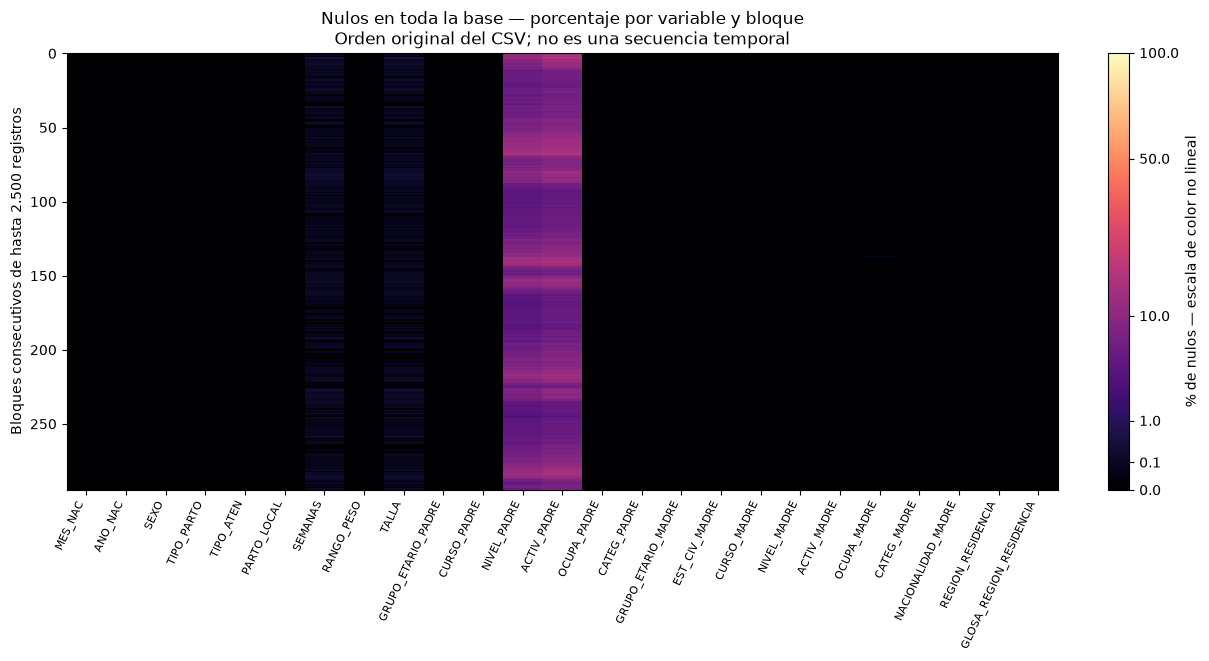

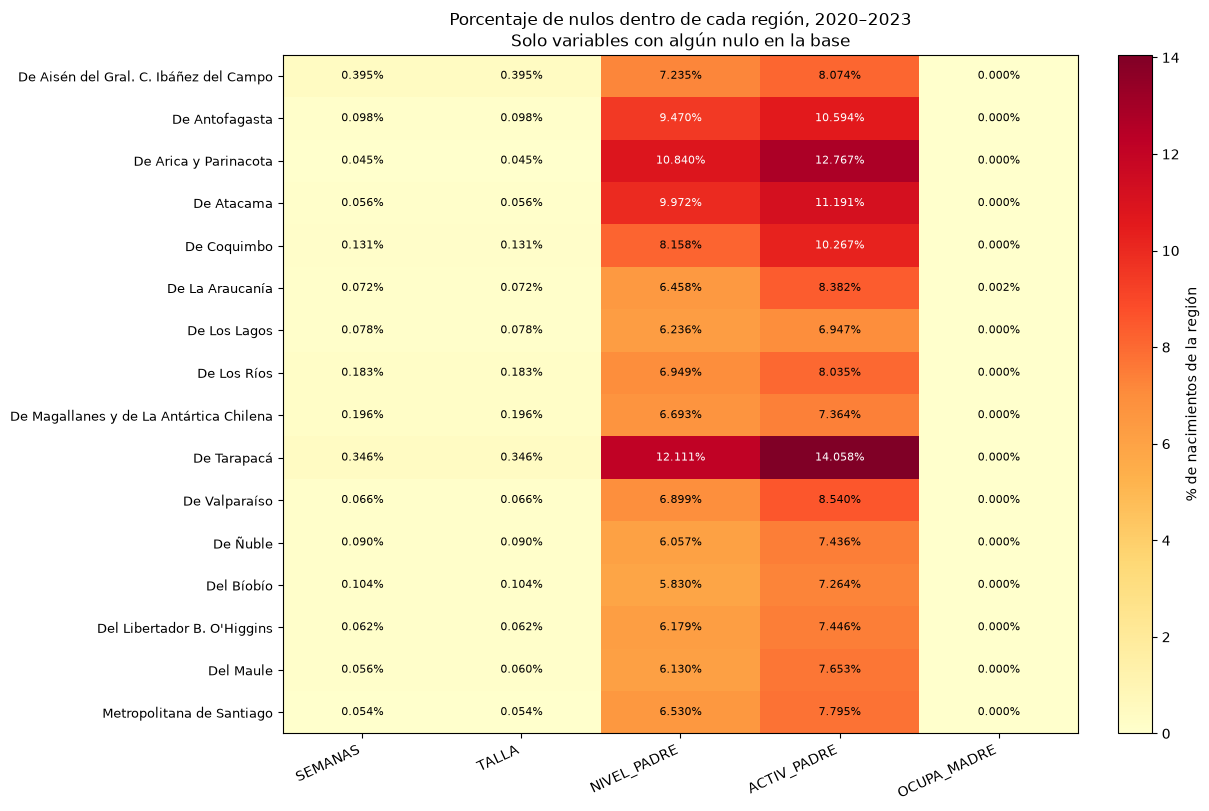

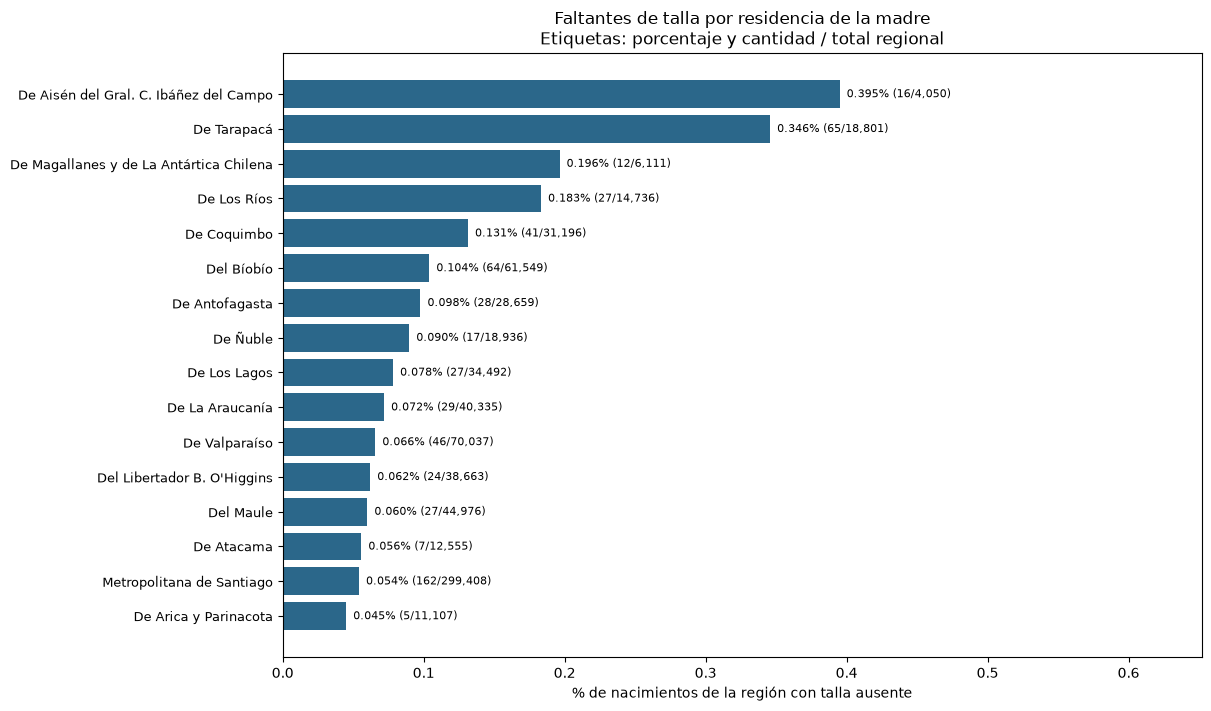

In [5]:
regional = u.faltantes_region(crudo)
talla_regional = regional[regional.variable.eq('TALLA')].sort_values('pct_nulos', ascending=False)
display(talla_regional[['REGION_RESIDENCIA','GLOSA_REGION_RESIDENCIA','nacimientos','nulos','pct_nulos']])
figuras = u.graficar_nulos(crudo, regional)
for nombre, fig in figuras.items():
    fig.savefig(FIGURAS / f'{nombre}.png', dpi=150)
    display(fig)
    plt.close(fig)

### Coocurrencia de faltantes
Se verifica cuántos registros carecen simultáneamente de talla y semanas de gestación. Una coincidencia
puede sugerir un patrón de registro para investigar, pero no demuestra su causa ni que los datos falten
al azar. No se concluirá MCAR, MAR o MNAR a partir de este diagnóstico descriptivo.

In [6]:
COOCURRENCIA = {
    'talla_y_semanas_ausentes': int((crudo.TALLA.isna() & crudo.SEMANAS.isna()).sum()),
    'solo_talla_ausente': int((crudo.TALLA.isna() & crudo.SEMANAS.notna()).sum()),
    'solo_semanas_ausentes': int((crudo.TALLA.notna() & crudo.SEMANAS.isna()).sum()),
}
display(pd.DataFrame([COOCURRENCIA]))

,talla_y_semanas_ausentes,solo_talla_ausente,solo_semanas_ausentes
0,595,2,0


## 4. Preparación y revisión de extremos
Se conservan las seis variables principales y se crean columnas derivadas. La copia original permanece
en memoria y el CSV original se conserva en disco. Los nulos de campos paternos se documentan, pero esos
campos no se incorporan a la tabla analítica porque no intervienen en las tres preguntas.

Se validan año, mes, región y edad materna. Las claves inválidas detienen el flujo: no se imputan.
Se quitan espacios externos de las etiquetas, se declara el orden de las edades y se crea `madre_menor_20`.
La columna `periodo_mes` representa un mes, sin inventar el día individual de nacimiento.

Una talla no numérica, infinita o no positiva se marca como inválida técnica y se separa para revisión.
Los valores positivos extremos se conservan. El criterio RIC es estadístico, no un límite clínico;
no se eliminarán tallas bajas simplemente por estar lejos de la mediana.

,minimo,maximo,q1,q3,limite_ric_inferior,limite_ric_superior,n_fuera_ric,pct_fuera_ric
0,17.0,53.0,48.0,50.0,45.0,53.0,24586,3.34497


Tallas inválidas técnicas: 0
Etiquetas de edad con espacios retirados: 0


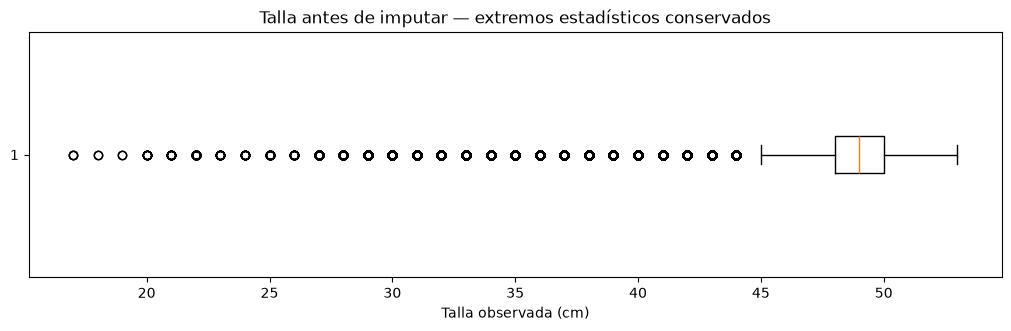

In [7]:
preparado = u.preparar(crudo)
ATIPICOS = u.resumen_atipicos(preparado.talla_observada_cm)
display(pd.DataFrame([ATIPICOS]))
print('Tallas inválidas técnicas:', int(preparado.talla_invalida_tecnica.sum()))
print('Etiquetas de edad con espacios retirados:', int(crudo.GRUPO_ETARIO_MADRE.ne(crudo.GRUPO_ETARIO_MADRE.astype('string').str.strip()).sum()))
fig, ax = plt.subplots(figsize=(10,3.2), layout='constrained')
ax.boxplot(preparado.talla_observada_cm.dropna(), orientation='horizontal')
ax.set_xlabel('Talla observada (cm)')
ax.set_title('Talla antes de imputar — extremos estadísticos conservados')
fig.savefig(FIGURAS / 'talla_observada_boxplot.png', dpi=150)
display(fig); plt.close(fig)

## 5. Comparación de tratamientos de talla
Se comparan cuatro escenarios sobre la misma población:

| Escenario | Tratamiento |
|---|---|
| Sin imputar | Calcular talla solo entre registros válidos. No eliminar nacimientos de la tabla general. |
| Media general | Completar con la media observada del período. |
| Mediana general | Completar con la mediana observada del período. |
| Mediana regional | Completar con la mediana de la región; usar la general si una región no tiene tallas válidas y registrar esos casos. |

Se comparan medias, dispersión y cambios por región. Ninguna diferencia pequeña demuestra que el valor
imputado sea correcto. El método que menos cambie la dispersión no es automáticamente el mejor.
No hay modelo predictivo ni partición entrenamiento/prueba en este proyecto.

In [8]:
escenarios, comparacion, sensibilidad = u.comparar_imputacion(preparado)
display(comparacion)
display(sensibilidad.pivot(index='GLOSA_REGION_RESIDENCIA', columns='metodo', values='cambio_media_cm').round(6))
extremos = []
for metodo, grupo in sensibilidad.groupby('metodo'):
    for tipo, valor in [('menor', grupo['mean'].min()), ('mayor', grupo['mean'].max())]:
        extremos.append({'metodo':metodo,'extremo':tipo,'regiones':'; '.join(grupo.loc[grupo['mean'].eq(valor),'GLOSA_REGION_RESIDENCIA']), 'media_cm':valor})
extremos = pd.DataFrame(extremos)
display(extremos)

,metodo,n_validos,n_imputados,excluidos_solo_calculo_talla,media_cm,mediana_cm,desv_cm,cambio_desv_pct,asimetria,respaldo_mediana_general
0,sin_imputar,735014,0,597,48.905500,49.0,2.402242,0.000000,-2.694501,0
1,media_general,735611,597,0,48.905500,49.0,2.401267,-0.040587,-2.695595,0
2,mediana_general,735611,597,0,48.905576,49.0,2.401268,-0.040524,-2.695686,0
3,mediana_region,735611,597,0,48.905670,49.0,2.401291,-0.039558,-2.695716,0


metodo,media_general,mediana_general,mediana_region,sin_imputar
GLOSA_REGION_RESIDENCIA,,,,
De Aisén del Gral. C. Ibáñez del Campo,-0.000267,0.000107,0.000107,0.0
De Antofagasta,0.000283,0.000375,0.000375,0.0
De Arica y Parinacota,-0.000190,-0.000147,0.000303,0.0
De Atacama,-0.000075,-0.000023,-0.000023,0.0
De Coquimbo,0.000068,0.000192,0.000192,0.0
De La Araucanía,0.000038,0.000106,0.000106,0.0
De Los Lagos,-0.000168,-0.000095,-0.000095,0.0
De Los Ríos,-0.000291,-0.000118,-0.000118,0.0
De Magallanes y de La Antártica Chilena,0.000361,0.000546,0.000546,0.0


,metodo,extremo,regiones,media_cm
0,media_general,menor,De Antofagasta,48.616363
1,media_general,mayor,De Arica y Parinacota,49.326508
2,mediana_general,menor,De Antofagasta,48.616456
3,mediana_general,mayor,De Arica y Parinacota,49.326551
4,mediana_region,menor,De Antofagasta,48.616456
5,mediana_region,mayor,De Arica y Parinacota,49.327001
6,sin_imputar,menor,De Antofagasta,48.616080
7,sin_imputar,mayor,De Arica y Parinacota,49.326698


### Propuesta de tratamiento para revisión del grupo
Se prepara una **propuesta con mediana regional**, porque utiliza el mismo ámbito regional de la pregunta
y permite un tratamiento sencillo. Su justificación se evaluará con la tabla anterior y el patrón de faltantes;
no se considera una decisión aprobada por el grupo ni una estimación de la talla real ausente.

Se conserva `talla_original`, la talla observada válida, una marca de imputación y el motivo del tratamiento.
El archivo se denomina `nacimientos_preparados_propuesta.csv` para distinguirlo de una versión definitiva.
El parámetro puede cambiarse a cualquier escenario comparado, incluido `sin_imputar`.

In [9]:
METODO_PROPUESTO = 'mediana_region'
assert METODO_PROPUESTO in escenarios
preparado['talla_analisis_cm'] = escenarios[METODO_PROPUESTO]
preparado['talla_imputada'] = preparado.talla_observada_cm.isna() & preparado.talla_analisis_cm.notna()
preparado['motivo_talla'] = np.select(
    [preparado.talla_invalida_tecnica, preparado.talla_ausente_original],
    ['invalida_tecnica', 'ausente_original'], default='observada')
calendario = u.calendario_periodo()
display(calendario.groupby('MES_NAC').dias.sum().rename('dias_acumulados').to_frame())
print('Método propuesto:', METODO_PROPUESTO)
print('Valores imputados:', int(preparado.talla_imputada.sum()))

,dias_acumulados
MES_NAC,
1,124
2,113
3,124
4,120
5,124
6,120
7,124
8,124
9,120


Método propuesto: mediana_region
Valores imputados: 597


## 6. Codificación y escalamiento según su propósito
La región se conserva como variable categórica nominal. No se aplica codificación one-hot porque los indicadores se calculan mediante agrupaciones y no requieren representar las categorías como columnas binarias.

## 7. Pruebas y validación
Se prueban entradas pequeñas conocidas, ausencia de faltantes, grupos sin talla válida, ausencia total
de tallas, categorías inesperadas, meses inválidos, columnas ausentes y escalas constantes.
Los ejemplos de prueba no son resultados de la población. La validación de la tabla completa verifica
que no se pierdan nacimientos ni se alteren tallas observadas y que los denominadores calendario sean correctos.

In [10]:
def exigir_error(tipo, funcion, *args):
    try:
        funcion(*args)
    except tipo:
        return True
    raise AssertionError(f'No se produjo la excepción esperada: {tipo.__name__}')

mini = pd.DataFrame({'ANO_NAC':[2020]*3, 'MES_NAC':[2]*3,
    'GRUPO_ETARIO_MADRE':['MENORES 15 AÑOS','15 A 19 AÑOS','20 A 24 AÑOS'],
    'REGION_RESIDENCIA':[1,1,2], 'GLOSA_REGION_RESIDENCIA':['R1','R1','R2'], 'TALLA':[48.,50.,np.nan]})
m = u.preparar(mini)
e, r, detalle = u.comparar_imputacion(m)
assert m.madre_menor_20.tolist() == [True,True,False]
assert e['mediana_region'].tolist() == [48.,50.,49.]
assert int(r.loc[r.metodo.eq('mediana_region'),'respaldo_mediana_general'].iloc[0]) == 1
sin_nulos = u.preparar(mini.assign(TALLA=[48.,50.,49.]))
assert u.comparar_imputacion(sin_nulos)[1].n_imputados.eq(0).all()
assert exigir_error(u.DatosError, u.comparar_imputacion, u.preparar(mini.assign(TALLA=np.nan)))
assert exigir_error(u.DatosError, u.preparar, mini.assign(MES_NAC=13))
assert exigir_error(u.DatosError, u.preparar, mini.assign(GRUPO_ETARIO_MADRE='NO DEFINIDO'))
assert exigir_error(u.DatosError, u.preparar, mini.drop(columns='TALLA'))
assert int(u.preparar(mini.assign(TALLA=[-1.,'texto',49.])).talla_invalida_tecnica.sum()) == 2
assert np.isfinite(u.comparar_escalas(pd.Series([49.,49.]))[['media','desv_poblacional']]).all().all()
assert u.validar(crudo, preparado, escenarios, calendario)
for variable in perfil.loc[perfil.nulos.gt(0),'variable']:
    assert regional.loc[regional.variable.eq(variable),'nulos'].sum() == crudo[variable].isna().sum()
assert u.huella(ARCHIVO) == SHA_ORIGINAL
print('Pruebas normales, límite y de excepción superadas. Filas y archivo original conservados.')

Pruebas normales, límite y de excepción superadas. Filas y archivo original conservados.


## 8. Persistencia, recursividad y trazabilidad
Se exportan tablas de calidad, comparaciones, figuras y una propuesta de datos preparados. La función
recursiva `aplanar` convierte los metadatos anidados en una tabla de rutas y valores; no recorre recursivamente
los nacimientos. Las salidas se regeneran al ejecutar F2. No se modifican documentos de F1 ni archivos Git.

In [11]:
bitacora = pd.DataFrame([
    ('Conservar nacimientos', len(crudo), 'No se eliminan filas por nulos de talla o por igualdad de atributos.'),
    ('Seleccionar variables principales', len(u.CLAVES), 'Se conserva el original de 25 columnas y su perfil completo.'),
    ('Marcar invalidez técnica de talla', int(preparado.talla_invalida_tecnica.sum()), 'No numérica, no finita o no positiva; conservar original.'),
    ('Conservar extremos estadísticos', ATIPICOS['n_fuera_ric'], 'RIC no demuestra error de registro.'),
    ('Imputación propuesta', int(preparado.talla_imputada.sum()), METODO_PROPUESTO + '; aprobado por el grupo.'),
], columns=['decision','cantidad','justificacion'])
tablas = {
    'perfil_variables': perfil,
    'faltantes_por_region': regional,
    'talla_faltantes_por_region': talla_regional,
    'comparacion_imputacion': comparacion,
    'sensibilidad_regional': sensibilidad,
    'extremos_sensibilidad': extremos,
    'calendario': calendario,
    'bitacora': bitacora
}
for nombre, tabla in tablas.items():
    tabla.to_csv(DOCS / f'{nombre}.csv', index=False)
salida = PROCESADOS / 'nacimientos_preparados_propuesta.csv'
preparado.to_csv(salida, index=False, encoding='utf-8')
verificacion_salida = pd.read_csv(salida, usecols=['ANO_NAC','talla_analisis_cm','talla_imputada'])
assert len(verificacion_salida) == len(crudo)
assert np.allclose(verificacion_salida.talla_analisis_cm, preparado.talla_analisis_cm, equal_nan=True)
assert verificacion_salida.talla_imputada.sum() == preparado.talla_imputada.sum()
METADATOS = {'proyecto':{'grupo':2,'periodo':'2020–2023 acumulado'},
    'ejecucion':{'fecha':date.today().isoformat(),'python':platform.python_version(),'bibliotecas':VERSIONES},
    'fuente':{'archivo':ARCHIVO.name,'sha256':SHA_ORIGINAL,'filas':len(crudo),'columnas':len(crudo.columns)},
    'preparacion':{'metodo_propuesto':METODO_PROPUESTO,'decision_grupo':'por completar',
        'imputados':int(preparado.talla_imputada.sum()),'filas_iguales_adicionales':FILAS_IGUALES_ADICIONALES},
    'pendientes':{'fecha_descarga':'por completar','licencia':'por completar',
        'validacion_docente_transformaciones':'por completar','revision_equipo':'por completar'}}
assert u.aplanar({'a':{'b':3},'c':2}) == {'a.b':3,'c':2}
(DOCS / 'metadatos.json').write_text(json.dumps(METADATOS, ensure_ascii=False, indent=2), encoding='utf-8')
pd.DataFrame(u.aplanar(METADATOS).items(), columns=['ruta','valor']).to_csv(DOCS / 'metadatos_aplanados.csv', index=False)
print('Propuesta exportada:', salida.relative_to(RAIZ))
print('Tablas: docs/f2/ | Figuras: outputs/f2/ | Módulo: src/f2_utilidades.py')
display(bitacora)

Propuesta exportada: data\processed\nacimientos_preparados_propuesta.csv
Tablas: docs/f2/ | Figuras: outputs/f2/ | Módulo: src/f2_utilidades.py


,decision,cantidad,justificacion
0,Conservar nacimientos,735611,No se eliminan filas por nulos de talla o por ...
1,Seleccionar variables principales,6,Se conserva el original de 25 columnas y su pe...
2,Marcar invalidez técnica de talla,0,"No numérica, no finita o no positiva; conserva..."
3,Conservar extremos estadísticos,24586,RIC no demuestra error de registro.
4,Imputación propuesta,597,mediana_region; aprobado por el grupo.


## 9. Reflexión técnica
La celda siguiente genera observaciones desde los resultados ejecutados. El grupo debe revisarlas y
añadir su interpretación. Las diferencias regionales de faltantes no prueban la causa de la ausencia.
Las tallas medias de los escenarios se usan para evaluar sensibilidad, no como resultados definitivos aprobados.

In [12]:
mayor = talla_regional.iloc[0]
menor = talla_regional.iloc[-1]
max_cambio = float(sensibilidad.loc[sensibilidad.metodo.eq(METODO_PROPUESTO),'cambio_media_cm'].abs().max())
print(f'1. TALLA contiene {crudo.TALLA.isna().sum():,} nulos ({crudo.TALLA.isna().mean()*100:.4f} %).')
print(f'2. Mayor porcentaje regional: {mayor.GLOSA_REGION_RESIDENCIA}, {mayor.pct_nulos:.4f} % ({mayor.nulos} registros).')
print(f'   Menor porcentaje regional: {menor.GLOSA_REGION_RESIDENCIA}, {menor.pct_nulos:.4f} % ({menor.nulos} registros).')
print(f'3. {COOCURRENCIA["talla_y_semanas_ausentes"]} registros carecen simultáneamente de talla y semanas.')
print(f'4. Con {METODO_PROPUESTO}, el mayor cambio absoluto de una media regional es {max_cambio:.6f} cm.')
print(f'5. Se conservan los {len(crudo):,} nacimientos, incluidas {FILAS_IGUALES_ADICIONALES:,} filas iguales adicionales.')
print('6. Estos resultados no demuestran ausencia aleatoria ni que una imputación recupere el valor real.')

1. TALLA contiene 597 nulos (0.0812 %).
2. Mayor porcentaje regional: De Aisén del Gral. C. Ibáñez del Campo, 0.3951 % (16 registros).
   Menor porcentaje regional: De Arica y Parinacota, 0.0450 % (5 registros).
3. 595 registros carecen simultáneamente de talla y semanas.
4. Con mediana_region, el mayor cambio absoluto de una media regional es 0.000804 cm.
5. Se conservan los 735,611 nacimientos, incluidas 8,105 filas iguales adicionales.
6. Estos resultados no demuestran ausencia aleatoria ni que una imputación recupere el valor real.


### Reflexión propia y pendientes
Se definio que la imputación propuesta seria la mediana por región.
Las preguntas a responder en este proyecto no requieren tratamiento de codificación y escalamiento.

**Por completar por el grupo:** revisar con la ficha los valores extremos y posibles códigos especiales; registrar dependencias; incorporar la versión
actual del método y sus resultados al informe.

Ideas para redactar conclusiones:
- Comparar tasas regionales de ausencia aporta información distinta de contar nulos a nivel nacional.
- Conservar la talla observada y una marca de imputación permite auditar el efecto de cada tratamiento.
- Las filas iguales no pueden interpretarse automáticamente como errores sin un identificador individual.
- La elección de transformaciones debe responder a un análisis descriptivo interpretable; por eso las
  tallas se mantienen en centímetros y los códigos regionales no se tratan como magnitudes.

Una de las dificultades que pudimos apreciar en la ejecución del proyecto fue la coordinación del equipo. Además de la utilización de la herramienta git y github. Ya que algunos cambios se pisaban y era desafiante mantener la coordinación, para resolver esto se utilizaron videollamadas por zoom para coordinar entre los integrantes.
Además el uso de estas tecnologías también fue desafiante puesto que los integrantes no estaban familiarizados con esta.

## 10. Verificación antes de entregar
- Ejecutar desde un kernel reiniciado y conservar las salidas del notebook.
- Verificar las rutas, la versión del CSV y las dependencias exactas.
- Revisar ambos mapas de calor y la tabla de denominadores regionales.
- Confirmar que el archivo original no cambió y que la propuesta conserva todas las filas.
- Aprobar el tratamiento de talla y actualizar informe, README y decisiones pendientes.
- Registrar revisión cruzada y contribuciones reales en Git.


### Referencias
- DEIS/MINSAL. (s. f.). *Serie de nacimientos 2020–2023 y Fichas DA Nacimientos*.
  https://deis.minsal.cl/#datosabiertos
- Universidad Andrés Bello. (s. f.). *S1_F2_Preprocesamiento.ipynb* [Notebook docente, MCDI500].
- Universidad Andrés Bello. (s. f.). *Guía de desarrollo de la Evaluación Sumativa 1 Fases 1 y 2*.